# Introduction

<center>
<h2>
Computational Experiments with Modern Parametrized Gaussian Error Linear Unit (MPGELU)
</h2>
<b>A demonstration by: Jose Aries E. De Los Santos</b>
</center>

# Import Libraries

In [1]:
import os
import sys
from pathlib import Path

#PyTorch
import torch as torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader
import time 
from torchinfo import summary

import pandas as pd
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
import random
from typing import Iterable, Callable


#sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Import torchvision
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
from torchvision.transforms import ToTensor
from torchinfo import summary

#Import tqdm for a cool progress bar
from tqdm.auto import tqdm

# Measure time
from timeit import default_timer as timer

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)


print(f"PyTorch Version: {torch.__version__}")
print(f"Numpy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"Matplotlib Version: {matplotlib.__version__}")
print(f"SciPy Version: {scipy.__version__}")

device = "cuda" if torch.cuda.is_available() else "cpu"

PyTorch Version: 2.5.1
Numpy Version: 1.26.4
Pandas Version: 3.0.5
Matplotlib Version: 3.11.0
SciPy Version: 1.16.0


# Dynamic Path Modification

* It is a runtime technique used to explicitly tell Python where to look for modules or packages when you run an ``import`` statement.

In [2]:
### Add the parent directory to the sys.path to import MyCNN and MPGELU
path1  = str(Path.cwd().parents[0])
if path1 not in sys.path:
    sys.path.append(path1)

## Import Helper Functions

In [3]:
from MPGELU import MPGELU
from PGELU import PGELU
from MyCNN import MyCNN
from DataTransforms import DataTransforms
from Trainer import Trainer

# MP GELU

* Modified Parametric Gaussian Error Linear Unit 
$$
f(x) = \frac{x}{2} \left[ 1 + \text{erf}\left( \frac{\lambda x}{\sqrt{2}}\right)\right] = \frac{x}{2} + \frac{x}{\sqrt{\pi}}\int_{0}^{\lambda x / \sqrt{2}} e^{-u^{2}}du
$$
where $\lambda  = (1 + \ln(1 + e^{s})) \geq 1$   $\forall s \in \mathbb{R}$

* Check MPGELU.py file for the implementation of the MPGELU activation function

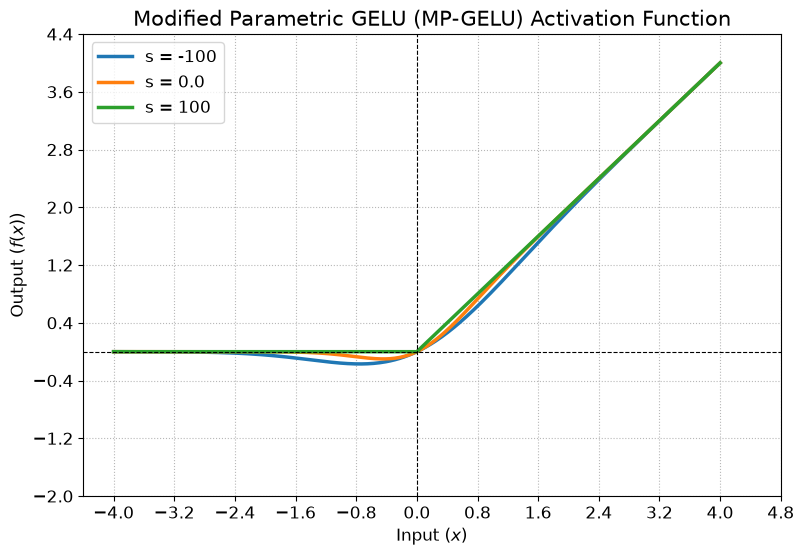

In [4]:
x_np = np.linspace(-4.0, 4.0, 400)
x_tensor = torch.tensor(x_np, dtype=torch.float32)
# s_values = np.arange(-2.0, 2.0, 0.1)
s_values = [-100, 0.0, 100, ]
plt.figure(figsize=(9, 6))

for s_val in s_values:
    activation1 = MPGELU(s_param=s_val)
    activation2 = MPGELU(s_param=s_val, use_softplus=False)
    with torch.no_grad():
        y_tensor1 = activation1(x_tensor)
        y_tensor2 = activation2(x_tensor)

    lam_val = (1.0 + F.softplus(torch.tensor(s_val, dtype=torch.float32))).item()
    plt.plot(x_np, y_tensor1.numpy(), label=f"s = {s_val}", linewidth=2.5)
    # plt.plot(x_np, y_tensor2.numpy(), label=f"s = {s_val}", linewidth=2)

# 4. Format the plot
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Modified Parametric GELU (MP-GELU) Activation Function", fontsize=15)
xticks = np.arange(-4, 5, 0.8)
plt.xticks(xticks,fontsize=12)
plt.xlabel("Input ($x$)", fontsize=12)
yticks = np.arange(-2, 5, 0.8)
plt.yticks(yticks,fontsize=12)
plt.ylabel("Output ($f(x)$)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.9)
plt.legend(fontsize=12)
plt.show()


# Data Processing

In [ ]:

transformer = DataTransforms(dataset='cifar10', use_augmentation=True, use_stats=False)
train_transform = transformer.get_train_transform()
test_transform = transformer.get_test_transform()


train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)


train_dataloader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_dataloader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

  3%|▎         | 5.11M/170M [00:31<16:22, 168kB/s] 

## Visualize Sample Images

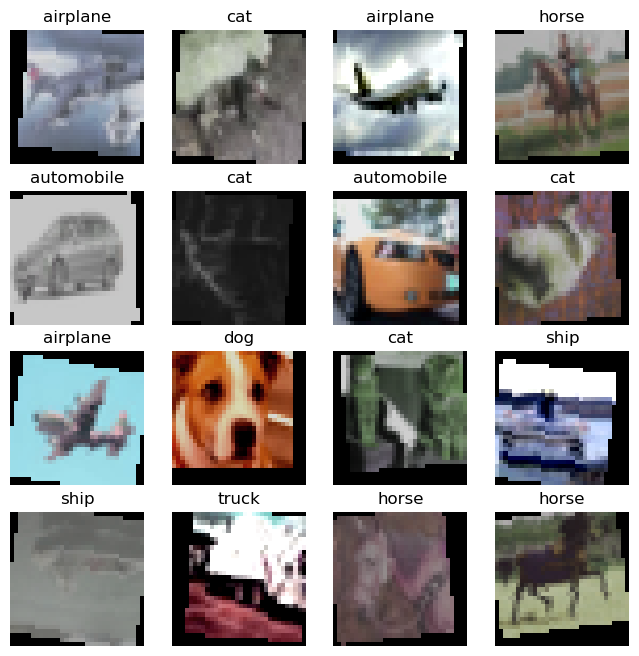

In [ ]:
fig = plt.figure(figsize=(8, 8))
rows, columns = 4, 4

for i in range(1, rows * columns + 1):
    idx = torch.randint(0, len(train_data), size=[1]).item()  # Random index
    img, label = train_data[idx][0], train_data[idx][1]
    fig.add_subplot(rows, columns, i)
    
    # Display image without converting to grayscale
    plt.imshow(img.permute(1, 2, 0))  # Change channels to last dimension (H, W, C)
    plt.title(train_data.classes[label])
    plt.grid(False)
    plt.axis(False)

plt.axis(False)
# plt.savefig("cifar10_dataset.jpg",dpi=800, bbox_inches="tight")
plt.show()

# Model

## Set its Parameters

In [ ]:
chosen_model_params = [32, 32, 'MaxPool', 64, 64, 'MaxPool', 128, 128, 128, 'MaxPool']

model = MyCNN(input_shape=3,
                  output_shape=10,
                  activation = MPGELU,
                  params = chosen_model_params).to(device)

print(summary(model=model,
        input = torch.randn(size=(3, 32, 32)).unsqueeze(dim=0)))

total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

Layer (type:depth-idx)                   Param #
MyCNN                                    --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       896
│    └─MPGELU: 2-2                       1
│    └─Conv2d: 2-3                       9,248
│    └─MPGELU: 2-4                       1
│    └─MaxPool2d: 2-5                    --
│    └─Conv2d: 2-6                       18,496
│    └─MPGELU: 2-7                       1
│    └─Conv2d: 2-8                       36,928
│    └─MPGELU: 2-9                       1
│    └─MaxPool2d: 2-10                   --
│    └─Conv2d: 2-11                      73,856
│    └─MPGELU: 2-12                      1
│    └─Conv2d: 2-13                      147,584
│    └─MPGELU: 2-14                      1
│    └─Conv2d: 2-15                      147,584
│    └─MPGELU: 2-16                      1
│    └─MaxPool2d: 2-17                   --
├─Sequential: 1-2                        --
│    └─Linear: 2-18                      524,544
│  

## Test Dummy Input

In [ ]:
dummy_input = torch.randn(1, 3, 32, 32).to(device)
model(dummy_input)

tensor([[-0.0362, -0.0129, -0.0656,  0.0272, -0.0346, -0.0435,  0.0302, -0.0474,
          0.0142, -0.0491]], device='cuda:0', grad_fn=<AddmmBackward0>)

# Training and Execution

## Setup loss, accuracy, and paramaters

In [ ]:
#Setup Loss Functions, Accuracy function
loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

#Define Accuracy Metric
def calculate_accuracy(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  accuracy = (correct / len(y_pred)) * 100
  return accuracy

##Training Parameters

num_of_epochs = 60
num_loss_steps = 5


## Execution and Saving

In [ ]:
activation_dict = {
    "MP_GELU": MPGELU,
    "PGELU": PGELU,
    "ReLU": torch.nn.ReLU,
    "GELU": torch.nn.GELU,
    "LeakyReLU": torch.nn.LeakyReLU
}

all_results = {}

for act_name, act_fn in activation_dict.items():
    print(f"\n=======================================================")
    print(f"       TRAINING WITH ACTIVATION: {act_name}")
    print(f"=======================================================")
    
    model = MyCNN(input_shape=3, output_shape=10, activation=act_fn, params=chosen_model_params).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    
    trainer = Trainer(model=model, loss_fn=loss_fn, optimizer=optimizer, 
                      calculate_accuracy=calculate_accuracy, device=device, loss_steps=num_loss_steps)
    
    results = {
        "train_loss": [], 
        "train_accu": [],
        "test_loss": [], 
        "test_accu": [],
        "activation_params": {} 
    }
    
    start_time = time.perf_counter()
    
    for epoch in tqdm(range(num_of_epochs), desc=f"Training {act_name}"):
        if epoch % num_loss_steps == 0:
            print(f"Epoch: {epoch} \n =====================================================================")
        train_loss, train_accu = trainer.train(data_loader=train_dataloader, epoch=epoch)
        test_loss, test_accu = trainer.test(data_loader=test_dataloader, epoch=epoch)
        
        results["train_loss"].append(train_loss)
        results["train_accu"].append(train_accu)
        results["test_loss"].append(test_loss)
        results["test_accu"].append(test_accu)
        
        # Track dynamic activation parameters
        for name, param in model.named_parameters():
            if 'alpha_param' in name or 'beta_param' in name or 's_param' in name:
                if name not in results.setdefault("activation_params", {}):
                    results["activation_params"][name] = []
                results["activation_params"][name].append(param.item())
                
    total_time = time.perf_counter() - start_time
    results["total_runtime"] = total_time
    all_results[act_name] = results
    
    # Save Model Checkpoint
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'results': results,
        'total_runtime': total_time,
        'activation_name': act_name 
    }
    
    save_dir = "model_trained_params"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"chkpt_{act_name}.pth")
    
    torch.save(checkpoint, save_path)
    print(f"Saved model state to {save_path}")


       TRAINING WITH ACTIVATION: MP_GELU


Training MP_GELU:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0 
Training Loss: 1.99185 | Training Accuracy: 28.22211%
Test Loss 1.71781 | Test Accuracy 42.87975%
Epoch: 1 


KeyboardInterrupt: 